# Introduction: Setting up an Experiment
more Infos

In [3]:
%load_ext autoreload
%autoreload 2

Add `SpheroidPy` package to the Python Path:

In [6]:
import sys
sys.path.append('..')

Additional Imports for the Tutorial:

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib as mpl
%matplotlib inline

### 1.) Creating a blank Experiment
Text

In [11]:
from SpheroidPy import Experiment # import the 'Experiment' class from package
example_experiment = Experiment('MyExperimentName', 96, Path('ExperimentFolder')) # for ease replace the 'ExperimentFolder' with the folder where the data regarding the experiment is stored

Text

In [13]:
example_experiment

EXPERIMENT: MyExperimentName  (96 Well Plate)

 Elements:
 > Platemaps(0): 
 > Results(0): 
 > AnalysisJobs(0): 

In [154]:
#example_experiment.hdf5_tree
pd.read_hdf(example_experiment.hdf5_path, key='Platemap/1-MyPlatemapName/cell_line/Hep3B')

,1,2,3,4,5,6,7,8,9,10,11,12
A,,,,,,,,,,,,
B,,20000.0,4000,800,160,32,,,,,,
C,,20000.0,4000,800,160,32,,,,,,
D,,20000.0,4000,800,160,32,,,,,,
E,,20000.0,4000,800,160,32,,,,,,
F,,20000.0,4000,800,160,32,,,,,,
G,,20000.0,4000,800,160,32,,,,,,
H,,,,,,,,,,,,


In [2]:
#new_experiment = Experiment.from_file(example_experiment.hdf5_path)

### 2.) Adding a Platemap

In [13]:
from SpheroidPy import Platemap    # first the 'Platemap' class has to be imported from the package
my_platemap = Platemap('MyPlatemapName', example_experiment)

In [15]:
#my_platemap.cell_line('Hep3B')

In [17]:
my_platemap.cell_line('Hep3B', {2e4: 'B2:G2', 4000: 'B3:G3', 800: 'B4:G4', 160: 'B5:G5', 32: 'B6:G6'})

Output()

/Users/cedric/Desktop/Labor/SpheroidPy/examples/../SpheroidPy/experiment/platemap.py:237: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12'], dtype='object')]

  df.to_hdf(self.hdf5_path, key=f'{self.hdf5_key}/{group_name}/{df_name}', mode='a')#, format='table')


In [19]:
my_platemap.replicates

{(('Hep3B', 20000.0),): ['B2', 'C2', 'D2', 'E2', 'F2', 'G2'],
 (('Hep3B', 4000.0),): ['B3', 'C3', 'D3', 'E3', 'F3', 'G3'],
 (('Hep3B', 800.0),): ['B4', 'C4', 'D4', 'E4', 'F4', 'G4'],
 (('Hep3B', 160.0),): ['B5', 'C5', 'D5', 'E5', 'F5', 'G5'],
 (('Hep3B', 32.0),): ['B6', 'C6', 'D6', 'E6', 'F6', 'G6']}

In [139]:
import pandas as pd

# Sample data with unique values in key columns for each row position
data = {
    'key1': [1, 2, 3, 4, 5],
    'key2': [10, 20, 30, 40, 50],
    'key3': [5, 15, 25, 35, 45],
}

df = pd.DataFrame(data)

# Calculate mean and std for each row (position) across key columns
df['mean'] = df.mean(axis=1)
df['std'] = df.std(axis=1)

print(df)

   key1  key2  key3       mean        std
0     1    10     5   5.333333   3.681787
1     2    20    15  12.333333   7.586538
2     3    30    25  19.333333  11.728408
3     4    40    35  26.333333  15.923428
4     5    50    45  33.333333  20.138410


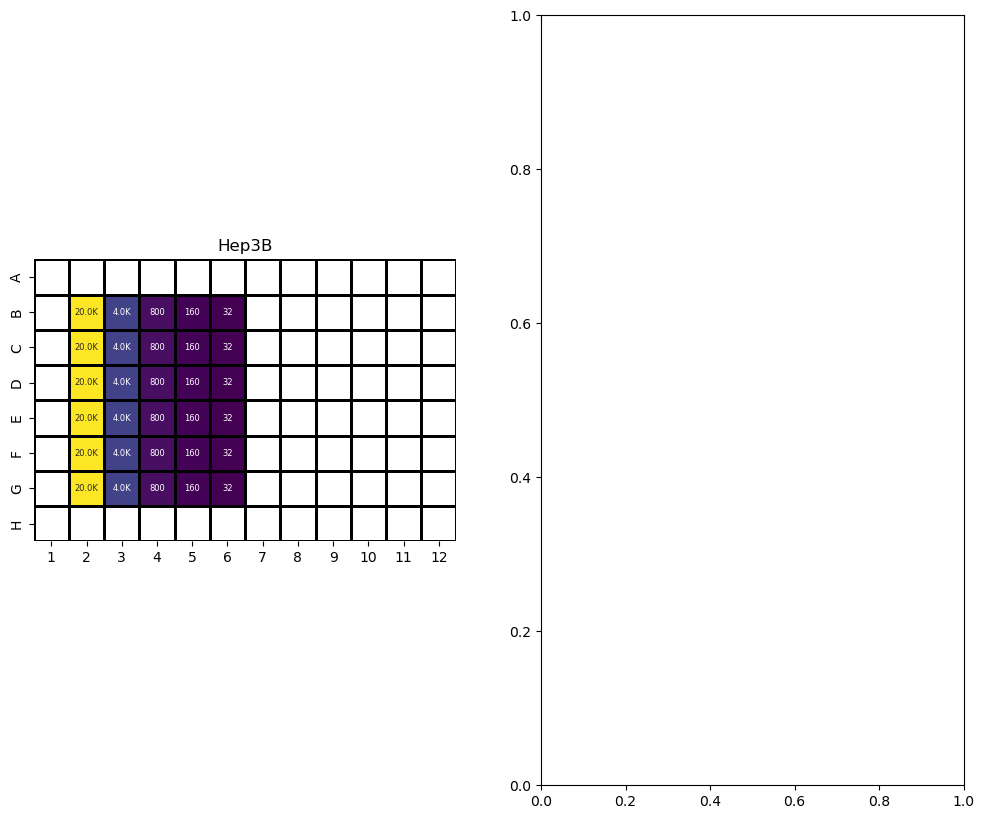

In [29]:
my_platemap.map
#my_platemap.save_all()

In [21]:
#my_result.results_mean

In [76]:
#my_result.results_mean

In [230]:
#my_result.df_results[['B2', 'C2', 'D2', 'E2', 'F2', 'G2']].mean(axis=1, skipna=True)

### 3.)  Loading Results

In [23]:
from SpheroidPy import Result

my_result = Result('MyFirstResult6', example_experiment)

In [4]:
from pathlib import Path

my_result.load_image_series(Path('/Users/cedric/Desktop/Labor/Data/Incucyte/SpheroidProliferation/Hep3B'),['PhaseContrast','raw'],['green'],['red'])

NameError: name 'my_result' is not defined

In [69]:
pd.set_option('display.float_format', '{:.1f}'.format)  # Maximal eine Nachkommastelle
pd.set_option('display.max_columns', None)               # Alle Spalten anzeigen
pd.set_option('display.max_rows', None)   
pd.set_option('display.width', None)                     # Maximale Breite anzeigen

#df = my_result.df_results
#df.loc[(df.index >= 202) & (df.index <= 260)]
#df

In [109]:
#my_result.files_dict

In [145]:
len(my_result.files_dict['fluorescence_red']['D2'])

227

In [94]:
spheroid_series = my_result.spheroid_dict['E6']
spheroid_series.spheroid_image_dict

{'2024-09-17 04:00:00': <SpheroidPy.spheroid.spheroid_image.SpheroidImage at 0x399376d70>,
 '2024-09-17 06:00:00': <SpheroidPy.spheroid.spheroid_image.SpheroidImage at 0x33ee893c0>,
 '2024-09-17 08:00:00': <SpheroidPy.spheroid.spheroid_image.SpheroidImage at 0x39863ded0>,
 '2024-09-17 10:00:00': <SpheroidPy.spheroid.spheroid_image.SpheroidImage at 0x33c0755d0>,
 '2024-09-17 12:00:00': <SpheroidPy.spheroid.spheroid_image.SpheroidImage at 0x3982deb00>,
 '2024-09-25 12:00:00': <SpheroidPy.spheroid.spheroid_image.SpheroidImage at 0x398b21090>}

In [96]:
spheroid_series.interactive(3)

In [51]:
pd.read_hdf(my_platemap.hdf5_path, key="/Platemap/1-MyPlatemapName/cell_line/Hep3B")

,1,2,3,4,5,6,7,8,9,10,11,12
A,,,,,,,,,,,,
B,,20000.0,4000.0,800.0,160.0,32.0,,,,,,
C,,20000.0,4000.0,800.0,160.0,32.0,,,,,,
D,,20000.0,4000.0,800.0,160.0,32.0,,,,,,
E,,20000.0,4000.0,800.0,160.0,32.0,,,,,,
F,,20000.0,4000.0,800.0,160.0,32.0,,,,,,
G,,20000.0,4000.0,800.0,160.0,32.0,,,,,,
H,,,,,,,,,,,,


In [224]:
df=my_platemap.cell_lines['Hep3B']

In [222]:
my_platemap.replicates

{(('Hep3B', 20000.0),): ['B2', 'C2', 'D2', 'E2', 'F2', 'G2'],
 (('Hep3B', 4000.0),): ['B3', 'C3', 'D3', 'E3', 'F3', 'G3'],
 (('Hep3B', 800.0),): ['B4', 'C4', 'D4', 'E4', 'F4', 'G4'],
 (('Hep3B', 160.0),): ['B5', 'C5', 'D5', 'E5', 'F5', 'G5'],
 (('Hep3B', 32.0),): ['B6', 'C6', 'D6', 'E6', 'F6', 'G6']}

In [238]:
df.loc['B', '3']

4000.0

In [360]:
spheroid2 = SpheroidImage(path_phase, path_green, path_red)

Segmentation type thresholding not possible! No Spheroid detected


In [2]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')

#import pandas as pd
#import numpy as np
from pathlib import Path

from SpheroidPy.spheroid.spheroid_image import SpheroidImage

AI
[11/13 01:04:42 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /Users/cedric/Desktop/Labor/SpheroidPy/SpheroidPy/weights/detectron_model_final.pth ...
[array([[[737, 344]],

       [[736, 345]],

       [[735, 345]],

       ...,

       [[740, 345]],

       [[739, 345]],

       [[738, 344]]], dtype=int32)]
True 1392 1038
[[737. 344.]
 [736. 345.]
 [735. 345.]
 ...
 [740. 345.]
 [739. 345.]
 [738. 344.]]


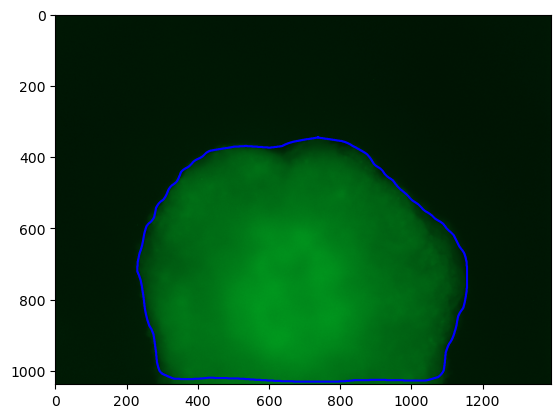

In [123]:
from pathlib import Path
#import cv2

path_phase = Path('/Users/cedric/Desktop/Labor/Data/Incucyte/SpheroidProliferation/Hep3B/PhaseContrast_raw/Hep3B_SpheroidGrowth_PhaseContrast_raw_D2_1_2024y09m18d_20h00m.tif')
path_green = Path('/Users/cedric/Desktop//Labor/Data/Incucyte/SpheroidProliferation/Hep3B/fluo_green/Hep3B_SpheroidGrowth_Fluorescence_screen_green_D2_1_2024y09m18d_20h00m.tif')
path_red = Path('/Users/cedric/Desktop/Labor/Data/Incucyte/SpheroidProliferation/Hep3B/fluo_red/Hep3B_SpheroidGrowth_Fluorescence_screen_red_D2_1_2024y09m18d_20h00m.tif')
path=[path_phase,path_green]
name=['a','b']

[(n_,p_) for n_ in name for p_ in path]

ar = [('phase_contrast', path_phase), ('fluorescence_green', path_green), ('fluorescence_red', path_red)]

spheroid = SpheroidImage(path_phase, path_green, path_red, segmentation = ('ai','brightfield'))

import matplotlib.pyplot as plt
plt.figure()
plt.imshow(spheroid.fluorescence('red'))
plt.imshow(spheroid.brightfield())
plt.plot(spheroid.contour[:,0], spheroid.contour[:,1], color='b')
#plt.plot(spheroid.contur_cut[:,0], spheroid.contur_cut[:,1], color='g')
#plt.plot(spheroid.fitted_contour[:,0], spheroid.fitted_contour[:,1])
#plt.plot(contour_combined[:,0], contour_combined[:,1], color='r')

In [46]:
import matplotlib.pyplot as plt

def custom_mask(img):
    """
    Image segmentation function to create a custom polygon mask, and evalute radius and position of the masked object.
    Need to use %matplotlib qt in jupyter notebook
    Args:
        img(array): Grayscale image as a Numpy array
    Returns:
        dict: Dictionary with keys: mask, radius, centroid (x/y)
    """

    height = img.shape[0]
    width  = img.shape[1]
    # click polygon mask interactive
    plt.ion()  
    plt.imshow(img, extent=[0, width, height, 0])
    plt.text(0.5, 1.05,'Click Polygon Mask with left click, finish with right click',  fontsize=12,
         horizontalalignment='center',
         verticalalignment='center',c='darkred', transform= plt.gca().transAxes)#     transform = ax.transAxes)
    # click the mask here
    print("Clicking the mask manual:")
    print(" // In spyder this function may freeze and cause the software to stop. A solution is going to the spyder settings and changing the Ipython Console Graphics Backend to Tkinter")
    my_roi = RoiPoly(color='r')   
    # Extract mask and segementation details
    mask = np.flipud(my_roi.get_mask(img))   # flip mask due to imshow 
    # determine radius of spheroid
    radius = np.sqrt(np.sum(mask) / np.pi)
    # determine center of mass
    cy, cx = center_of_mass(mask)
    # hide pop-up windows   
    plt.ioff()
    # return dictionary containing spheroid information
    return {'mask': mask, 'radius': radius, 'centroid': (cx, cy)} 

img = cv2.im
custom_mask(img)

['brightfield', 'fluorescence_green', 'fluorescence_red']

In [23]:
def mesh(arr, max_area: float = 500, plot: bool = True, accuracy: int = 1):
    from meshpy.triangle import MeshInfo, build
    # Setup für MeshPy
    mesh_info = MeshInfo()
    mesh_info.set_points(arr[::accuracy].tolist())
    # Definiere Kanten der Kontur
    segments = [(i, (i + 1) % len(arr[::accuracy])) for i in range(len(arr[::accuracy]))]
    mesh_info.set_facets(segments)
    # Generiere das Mesh
    mesh = build(mesh_info, max_volume=max_area)
    points = np.array(mesh.points)
    triangles = np.array(mesh.elements)
    # Plot Mesh
    #plot_mesh(points, triangles) if plot else None
    return points, triangles

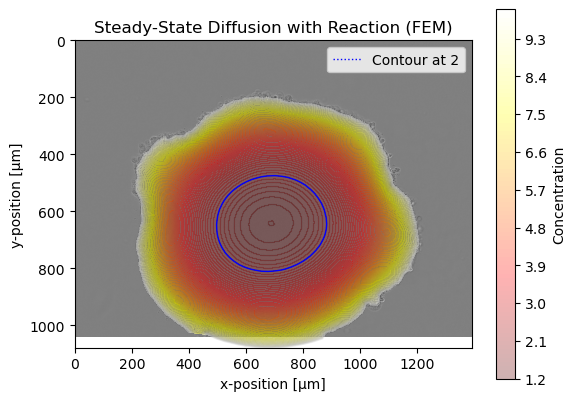

array([10.        , 10.        , 10.        , ...,  4.8673301 ,
        2.97728216,  1.5887725 ])

In [85]:
#spheroid.contour[::30]
spheroid.diffusion_stationary(diffusion_rate=5000, reaction_rate=.1)

#mesh(spheroid.contour)
#spheroid.mesh(accuracy=100, max_area=5000, plot=True)

In [191]:
# Konfiguration, um große Arrays vollständig anzuzeigen
np.set_printoptions(threshold=100)#np.inf)
spheroid.contour[::55]

array([[592., 178.],
       [537., 188.],
       [482., 209.],
       ...,
       [722., 213.],
       [667., 199.],
       [612., 189.]], dtype=float32)

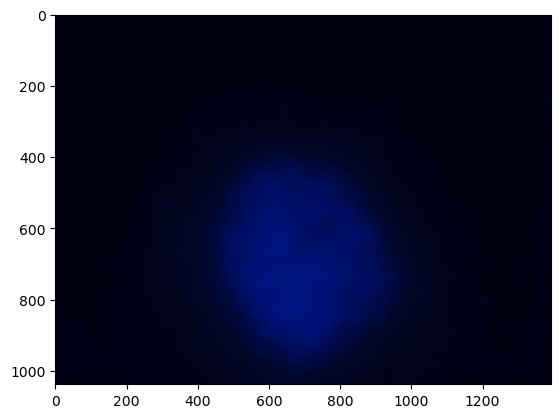

In [47]:
#plt.imshow(spheroid.brightfield())
plt.imshow(spheroid.fluorescence('red'))

[ 325. 1027.]


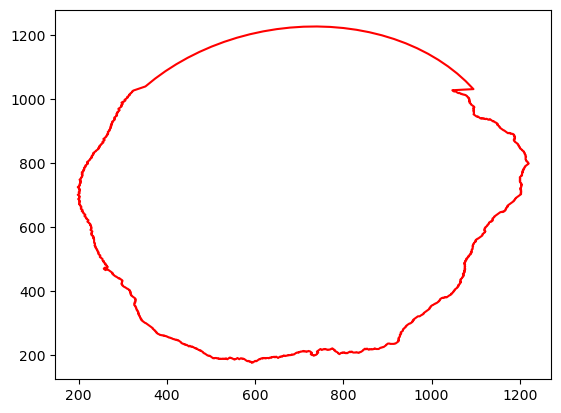

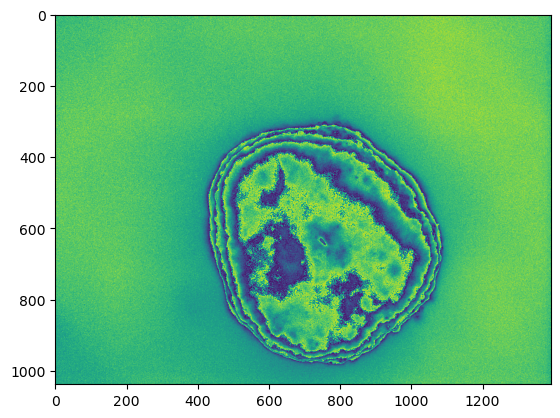

In [47]:
plt.imshow(spheroid._image(channel='fluorescence_green', contour=False, mono=True, mono_incr=5))

In [618]:
import pandas as pd
import numpy as np

# 1. Wells erstellen
rows = ["A", "B", "C", "D", "E", "F", "G", "H"]
cols = range(1, 13)
wells = [f"{row}{col}" for row in rows for col in cols]

# 2. Zeitpunkte erstellen
# Zum Beispiel für 10 Zeitpunkte, du kannst das entsprechend anpassen.
time_points = [f"Time_{i}" for i in range(1, 11)]

# 3. Leeres DataFrame erstellen (mit Zeitpunkten als Zeilen und Wells als Spalten)
#data = np.random.rand(len(time_points), len(wells))  # Zufällige Werte als Platzhalter
df = pd.DataFrame(float(np.nan), index=time_points, columns=wells)

# Ausgabe anzeigen
df.head()


[autoreload of SpheroidPy.experiment.result failed: Traceback (most recent call last):
  File "/opt/anaconda3/envs/lab/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/opt/anaconda3/envs/lab/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
  File "/opt/anaconda3/envs/lab/lib/python3.10/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 619, in _exec
  File "<frozen importlib._bootstrap_external>", line 883, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/Users/cedric/Desktop/Labor/SpheroidPy/examples/../SpheroidPy/experiment/result.py", line 17, in <module>
    from SpheroidPy.spheroid.spheroid_series import SpheroidSeries
  File "/Users/cedric/Desktop/Labor/SpheroidPy/examples/../SpheroidPy/spheroid/sphero

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12
Time_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time_5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
